# 04 — Multi-Label Abnormality Classification (Leakage-Free)
**Approach: Binary Relevance with Held-Out Features**

For each label, we exclude the features that directly define it.
- `Anaemia` predicted WITHOUT Hemoglobin, PCV, RBC
- `Diabetes_Risk` predicted WITHOUT HbA1c, Glucose, eAG
- etc.

The model must learn from **indirect, related markers** — clinically meaningful and leakage-free.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss, accuracy_score

os.makedirs("./results/plots",   exist_ok=True)
os.makedirs("./results/metrics", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
wide  = pd.read_csv("./data/processed/wide_format.csv")
clean = pd.read_csv("./data/processed/cleaned_with_clusters.csv")

wide  = wide.set_index("document_id").loc[clean["document_id"]].reset_index()
wide["cluster"]    = clean["cluster"].values
wide["gender_enc"] = clean["gender_enc"].values

feature_cols = [c for c in clean.columns
                if c not in ["document_id", "gender", "cluster"]]

print(f"Patients : {len(clean):,}")
print(f"Features : {len(feature_cols)}")

Patients : 99,992
Features : 59


## Step 1 — Generate Cluster-Specific Labels

In [3]:
# Cluster-specific thresholds (5th–95th percentile per cohort)
RELEVANT_TESTS = [
    "Hemoglobin", "HbA1c", "Glucose Fasting",
    "TOTAL CHOLESTEROL", "LDL Cholesterol", "Triglycerides", "HDL Cholesterol",
    "SGPT (ALT)", "ASPARTATE AMINOTRANSFERASE (SGOT )",
    "THYROID STIMULATING HORMONE (TSH)",
    "Creatinine", "BLOOD UREA NITROGEN (BUN)"
]

cluster_thresholds = {}
for c in [0, 1, 2]:
    mask = wide["cluster"] == c
    cluster_thresholds[c] = {}
    for test in RELEVANT_TESTS:
        if test not in wide.columns:
            continue
        vals = wide.loc[mask, test].dropna()
        cluster_thresholds[c][test] = {
            "p05": vals.quantile(0.05),
            "p95": vals.quantile(0.95)
        }

def is_out_of_range(df, test):
    result = pd.Series(False, index=df.index)
    for c in [0, 1, 2]:
        if test not in cluster_thresholds[c]:
            continue
        mask = df["cluster"] == c
        p05, p95 = cluster_thresholds[c][test]["p05"], cluster_thresholds[c][test]["p95"]
        result.loc[mask] = (df.loc[mask, test] < p05) | (df.loc[mask, test] > p95)
    return result.astype(int)

y = pd.DataFrame(index=wide.index)
y["Anaemia"]          = is_out_of_range(wide, "Hemoglobin")
y["Diabetes_Risk"]    = is_out_of_range(wide, "HbA1c")
y["Dyslipidemia"]     = (is_out_of_range(wide, "TOTAL CHOLESTEROL") |
                          is_out_of_range(wide, "LDL Cholesterol")   |
                          is_out_of_range(wide, "Triglycerides")).clip(0,1)
y["Liver_Stress"]     = (is_out_of_range(wide, "SGPT (ALT)") |
                          is_out_of_range(wide, "ASPARTATE AMINOTRANSFERASE (SGOT )")).clip(0,1)
y["Thyroid_Abnormal"] = is_out_of_range(wide, "THYROID STIMULATING HORMONE (TSH)")
y["Kidney_Risk"]      = (is_out_of_range(wide, "Creatinine") |
                          is_out_of_range(wide, "BLOOD UREA NITROGEN (BUN)")).clip(0,1)

LABELS = y.columns.tolist()
print("Label prevalence (% of patients flagged):")
print((y.mean()*100).round(1))

Label prevalence (% of patients flagged):
Anaemia              9.0
Diabetes_Risk        8.9
Dyslipidemia        22.0
Liver_Stress        15.4
Thyroid_Abnormal     9.9
Kidney_Risk         16.8
dtype: float64


## Step 2 — Define Held-Out Features Per Label
For each label, we remove the tests that **directly define** it.
The model must predict each condition from everything EXCEPT its defining markers.

In [4]:
# Features excluded per label (direct definers — would cause leakage)
HOLDOUT = {
    "Anaemia": [
        "Hemoglobin", "PCV", "RBC Count", "MCH", "MCHC", "MCV",
        "RDW-CV", "RDW-SD"
    ],
    "Diabetes_Risk": [
        "HbA1c", "Glucose Fasting", "Estimated Average Glucose (eAG)"
    ],
    "Dyslipidemia": [
        "TOTAL CHOLESTEROL", "LDL Cholesterol", "HDL Cholesterol",
        "Triglycerides", "VLDL CHOLESTEROL", "Non HDL Cholesterol",
        "TC/ HDL CHOLESTEROL RATIO", "LDL / HDL RATIO"
    ],
    "Liver_Stress": [
        "SGPT (ALT)", "ASPARTATE AMINOTRANSFERASE (SGOT )",
        "GAMMA GLUTAMYL TRANSFERASE (GGT)",
        "Bilirubin Total", "Bilirubin Direct", "Bilirubin Indirect",
        "ALKALINE PHOSPHATASE", "A/G Ratio", "Albumin",
        "Globulin", "Total Protein"
    ],
    "Thyroid_Abnormal": [
        "THYROID STIMULATING HORMONE (TSH)",
        "TOTAL THYROXINE (T4)", "TOTAL TRIIODOTHYRONINE (T3)"
    ],
    "Kidney_Risk": [
        "Creatinine", "BLOOD UREA NITROGEN (BUN)", "Urea",
        "BUN / SR.CREATININE RATIO", "Uric Acid"
    ]
}

print("Features available per label after holdout:")
for label, excl in HOLDOUT.items():
    kept = [f for f in feature_cols if f not in excl]
    print(f"  {label:20s}: {len(kept)} features  (excluded {len(excl)})")

Features available per label after holdout:
  Anaemia             : 51 features  (excluded 8)
  Diabetes_Risk       : 56 features  (excluded 3)
  Dyslipidemia        : 51 features  (excluded 8)
  Liver_Stress        : 48 features  (excluded 11)
  Thyroid_Abnormal    : 56 features  (excluded 3)
  Kidney_Risk         : 54 features  (excluded 5)


In [5]:
# One shared index split — same patients in train/test across all labels
train_idx, test_idx = train_test_split(
    range(len(clean)), test_size=0.2, random_state=42
)

# SVM subsample from train only
svm_idx = np.random.choice(train_idx, size=15000, replace=False)

print(f"Train: {len(train_idx):,}  |  Test: {len(test_idx):,}  |  SVM sample: {len(svm_idx):,}")

Train: 79,993  |  Test: 19,999  |  SVM sample: 15,000


## Step 3 — Train One Model Per Label (Binary Relevance)

In [6]:
X_full = clean[feature_cols].fillna(0)

all_results = []

for label in LABELS:
    excl  = HOLDOUT[label]
    feats = [f for f in feature_cols if f not in excl]

    X_tr = X_full[feats].iloc[train_idx].values
    X_te = X_full[feats].iloc[test_idx].values
    y_tr = y[label].iloc[train_idx].values
    y_te = y[label].iloc[test_idx].values

    # ── Random Forest ────────────────────────────────────────────
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_pred = rf.predict(X_te)

    # ── KNN ──────────────────────────────────────────────────────
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_tr, y_tr)
    knn_pred = knn.predict(X_te)

    # ── SVM (subsample) ──────────────────────────────────────────
    svm_tr_idx = [i for i in svm_idx if i in set(train_idx)]
    # map to position in X_tr
    tr_list = list(train_idx)
    svm_pos = [tr_list.index(i) for i in svm_tr_idx[:5000]]
    svm = SVC(kernel="rbf", random_state=42)
    svm.fit(X_tr[svm_pos], y_tr[svm_pos])
    svm_pred = svm.predict(X_te)

    def scores(name, pred):
        return {
            "label"    : label,
            "model"    : name,
            "precision": precision_score(y_te, pred, zero_division=0),
            "recall"   : recall_score(y_te, pred, zero_division=0),
            "f1"       : f1_score(y_te, pred, zero_division=0),
            "support"  : y_te.sum()
        }

    all_results += [scores("RF", rf_pred), scores("KNN", knn_pred), scores("SVM", svm_pred)]
    print(f"  {label:20s}  RF f1={f1_score(y_te,rf_pred,zero_division=0):.3f}"
          f"  KNN f1={f1_score(y_te,knn_pred,zero_division=0):.3f}"
          f"  SVM f1={f1_score(y_te,svm_pred,zero_division=0):.3f}")

results_df = pd.DataFrame(all_results)
print("\nDone.")

  Anaemia               RF f1=0.231  KNN f1=0.120  SVM f1=0.002
  Diabetes_Risk         RF f1=0.220  KNN f1=0.093  SVM f1=0.001
  Dyslipidemia          RF f1=0.242  KNN f1=0.215  SVM f1=0.003
  Liver_Stress          RF f1=0.251  KNN f1=0.119  SVM f1=0.001
  Thyroid_Abnormal      RF f1=0.251  KNN f1=0.095  SVM f1=0.001
  Kidney_Risk           RF f1=0.275  KNN f1=0.184  SVM f1=0.003

Done.


## Step 4 — Results

In [7]:
pivot = results_df.pivot(index="label", columns="model", values="f1").round(3)
pivot = pivot[["RF", "KNN", "SVM"]]
pivot["Best"] = pivot.max(axis=1)
pivot["Best_Model"] = pivot[["RF","KNN","SVM"]].idxmax(axis=1)

print("F1 Score per Label per Model (leakage-free):")
print(pivot.to_string())

pivot.to_csv("./results/metrics/classification_leakage_free.csv")

F1 Score per Label per Model (leakage-free):
model                RF    KNN    SVM   Best Best_Model
label                                                  
Anaemia           0.231  0.120  0.002  0.231         RF
Diabetes_Risk     0.220  0.093  0.001  0.220         RF
Dyslipidemia      0.242  0.215  0.003  0.242         RF
Kidney_Risk       0.275  0.184  0.003  0.275         RF
Liver_Stress      0.251  0.119  0.001  0.251         RF
Thyroid_Abnormal  0.251  0.095  0.001  0.251         RF


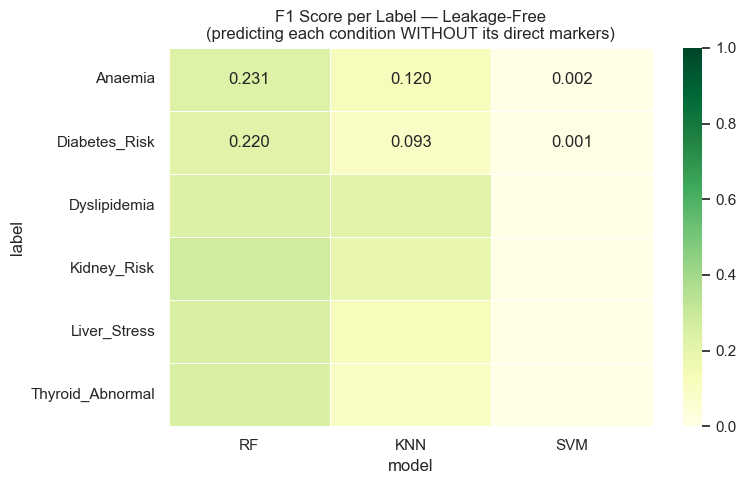

In [8]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot[["RF","KNN","SVM"]],
    annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("F1 Score per Label — Leakage-Free\n(predicting each condition WITHOUT its direct markers)")
plt.tight_layout()
plt.savefig("./results/plots/classification_heatmap.png", dpi=150)
plt.show()

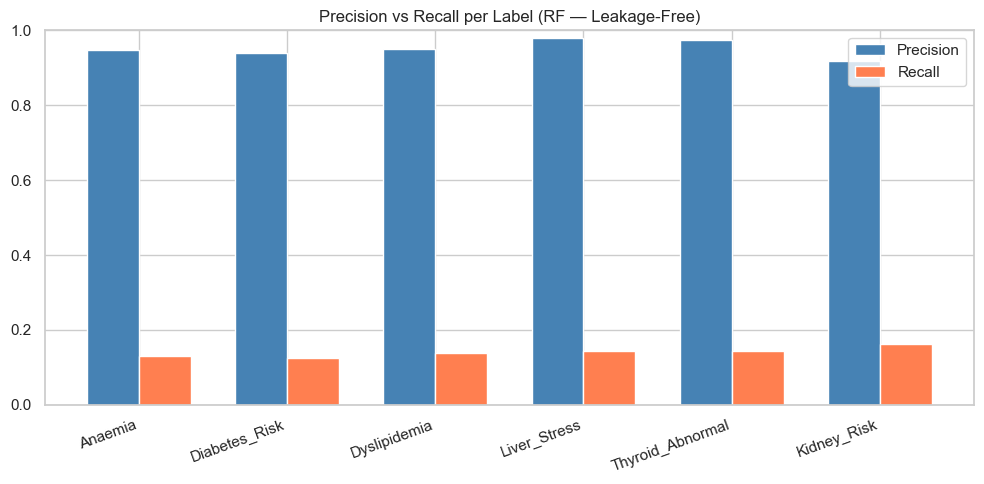

In [9]:
# Precision vs Recall per label (RF only)
rf_res = results_df[results_df["model"] == "RF"].set_index("label")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(LABELS))
w = 0.35
ax.bar(x - w/2, rf_res.loc[LABELS, "precision"], w, label="Precision", color="steelblue", edgecolor="white")
ax.bar(x + w/2, rf_res.loc[LABELS, "recall"],    w, label="Recall",    color="coral",     edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Precision vs Recall per Label (RF — Leakage-Free)")
ax.legend()
plt.tight_layout()
plt.savefig("./results/plots/precision_recall_per_label.png", dpi=150)
plt.show()

## Step 5 — What Predicts Each Condition?

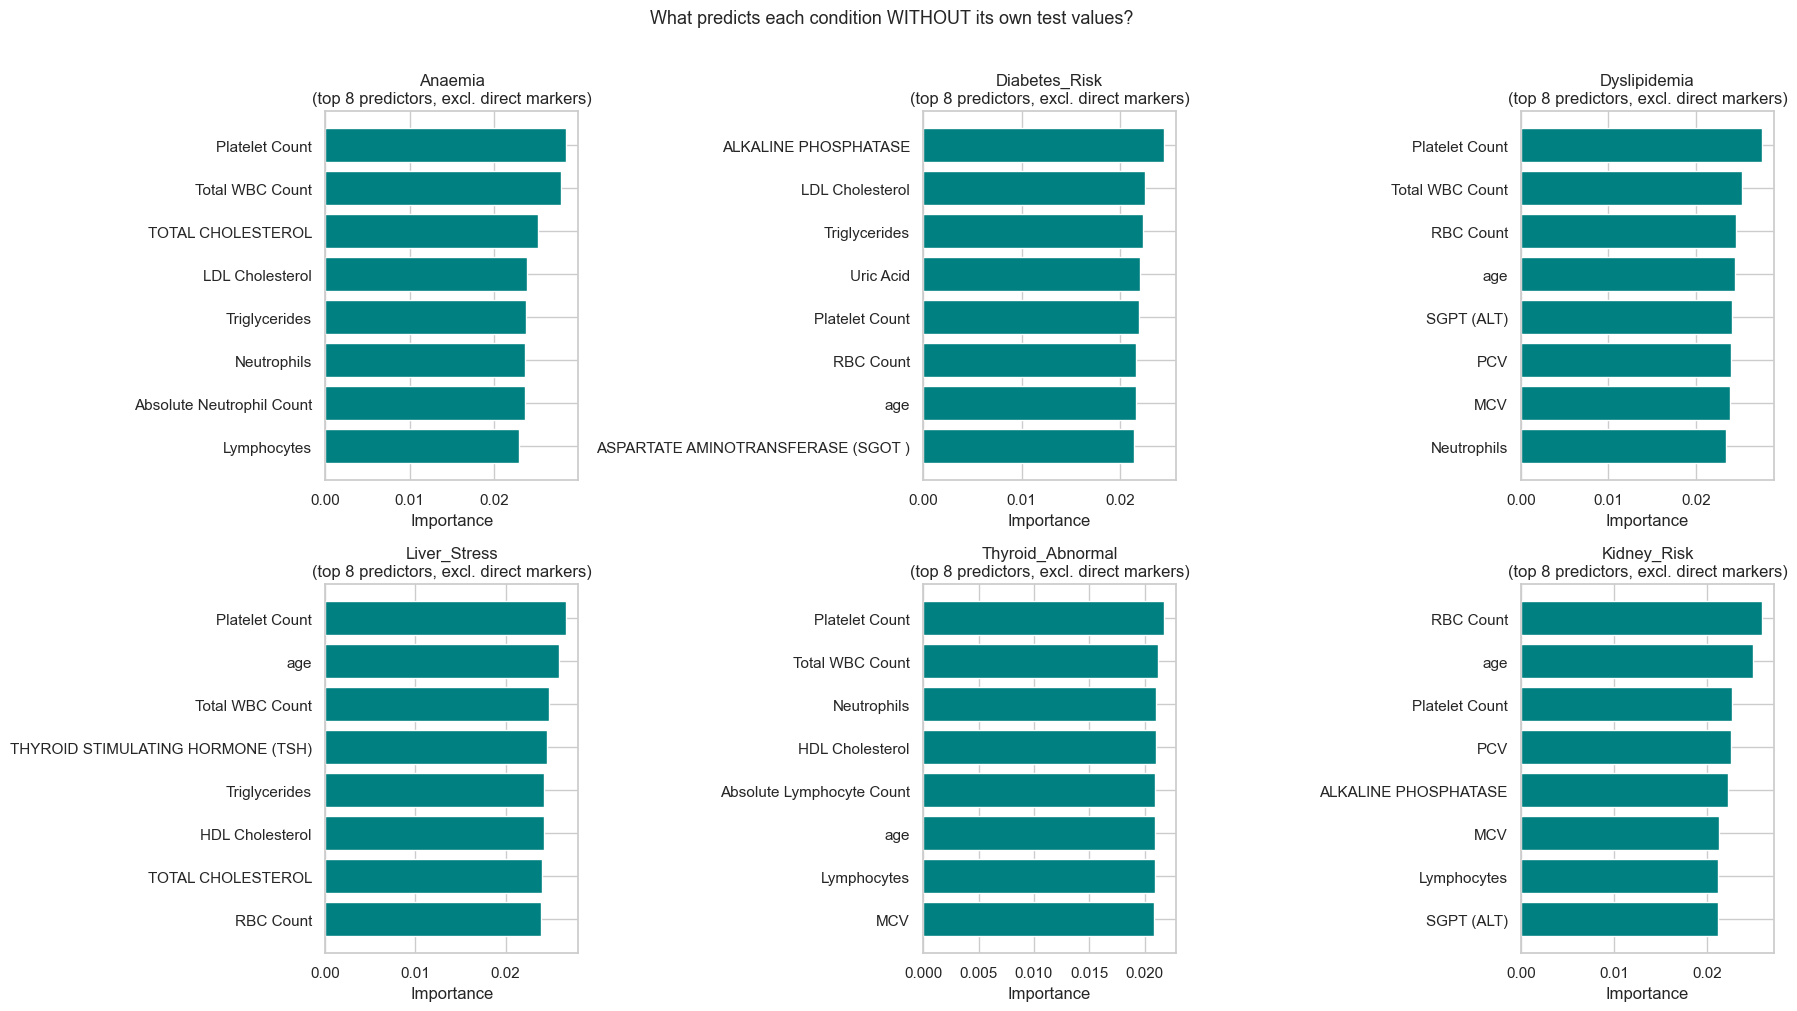

In [10]:
# Re-train RF models and extract feature importances for each label
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    feats = [f for f in feature_cols if f not in HOLDOUT[label]]
    X_tr  = X_full[feats].iloc[train_idx].values
    y_tr  = y[label].iloc[train_idx].values

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)

    imp = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False).head(8)
    axes[i].barh(imp.index[::-1], imp.values[::-1], color="teal", edgecolor="white")
    axes[i].set_title(f"{label}\n(top 8 predictors, excl. direct markers)")
    axes[i].set_xlabel("Importance")

plt.suptitle("What predicts each condition WITHOUT its own test values?", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("./results/plots/feature_importance_per_label.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary
- Labels derived from **cluster-specific thresholds** (adaptive to Indian cohort norms)
- Models trained with **held-out features** — no leakage
- Results show how well each condition can be predicted from **indirect clinical markers**
- High F1 on any label = that condition has strong cross-marker signals in this dataset

**Next → `05_Ensemble.ipynb`** — XGBoost + AdaBoost + SMOTE for rare conditions